# Cross-Sectional Visualization

This notebook creates visualizations for the cross-sectional analysis, including:
- Regression coefficients comparison across price groups
- Radar chart of normalized coefficients
- Other exploratory plots

**Data Source**: `data/processed/house_price_reg_processed.csv`
**Output**: All figures saved to `results/figures/`

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style and display options
plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")
pd.set_option('display.float_format', '{:.4f}'.format)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Project paths (relative to this notebook)
data_path = Path('../../data/processed/house_price_reg_processed.csv')
figures_dir = Path('../../results/figures/')

# Create figures directory
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"Data path: {data_path}")
print(f"Figures will be saved to: {figures_dir}")

Data path: ..\..\data\processed\house_price_reg_processed.csv
Figures will be saved to: ..\..\results\figures


In [4]:
# Load processed data
data = pd.read_csv(data_path)
print(f"Dataset loaded: {data.shape[0]:,} rows × {data.shape[1]} columns")

# Create price groups using quantiles (33% and 67%)
low_threshold = data['House_Price'].quantile(0.3333)
high_threshold = data['House_Price'].quantile(0.6667)

def categorize_price(row):
    if row['House_Price'] <= low_threshold:
        return "Low"
    elif row['House_Price'] <= high_threshold:
        return "Medium"
    else:
        return "High"

data['Price_Group'] = data.apply(categorize_price, axis=1)

print("\nPrice Group Distribution:")
print(data['Price_Group'].value_counts().sort_index())

Dataset loaded: 1,000 rows × 11 columns

Price Group Distribution:
Price_Group
High      333
Low       333
Medium    334
Name: count, dtype: int64


In [5]:
def run_regression(df):
    """Run OLS regression and return fitted model"""
    X = df[['Square_Footage', 'House_Age', 'Num_Bedrooms', 
            'Num_Bathrooms', 'Lot_Size', 'Garage_Size']]
    X = sm.add_constant(X)
    y = df['House_Price']
    model = sm.OLS(y, X).fit()
    return model

In [6]:
# Run regression for each group + overall
models = {}

for group in ['Low', 'Medium', 'High', 'Overall']:
    if group == 'Overall':
        group_data = data
    else:
        group_data = data[data['Price_Group'] == group]
    
    models[group] = run_regression(group_data)
    print(f"Regression completed for {group} group ({len(group_data)} observations)")

Regression completed for Low group (333 observations)
Regression completed for Medium group (334 observations)
Regression completed for High group (333 observations)
Regression completed for Overall group (1000 observations)


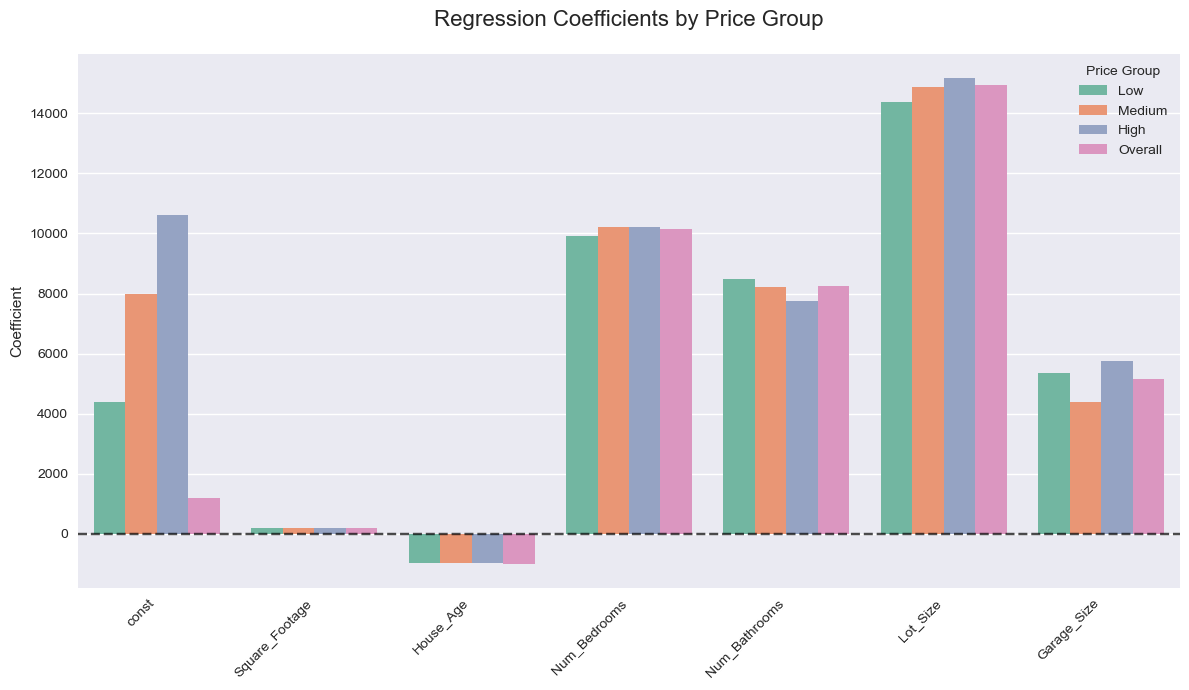

Bar chart saved: regression_coefficients_by_group.png


In [7]:
# Extract coefficients into a clean DataFrame
coef_data = []

for group, model in models.items():
    coef = model.params.reset_index()
    coef.columns = ['Variable', 'Coefficient']
    coef['Group'] = group
    coef_data.append(coef)

coef_df = pd.concat(coef_data, ignore_index=True)

# Plot: Regression Coefficients by Price Group
plt.figure(figsize=(12, 7))
sns.barplot(data=coef_df, x='Variable', y='Coefficient', hue='Group', palette='Set2')

plt.title('Regression Coefficients by Price Group', fontsize=16, pad=20)
plt.xlabel('')
plt.ylabel('Coefficient')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.legend(title='Price Group')
plt.tight_layout()

# Save figure
plt.savefig(figures_dir / 'regression_coefficients_by_group.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Bar chart saved: regression_coefficients_by_group.png")

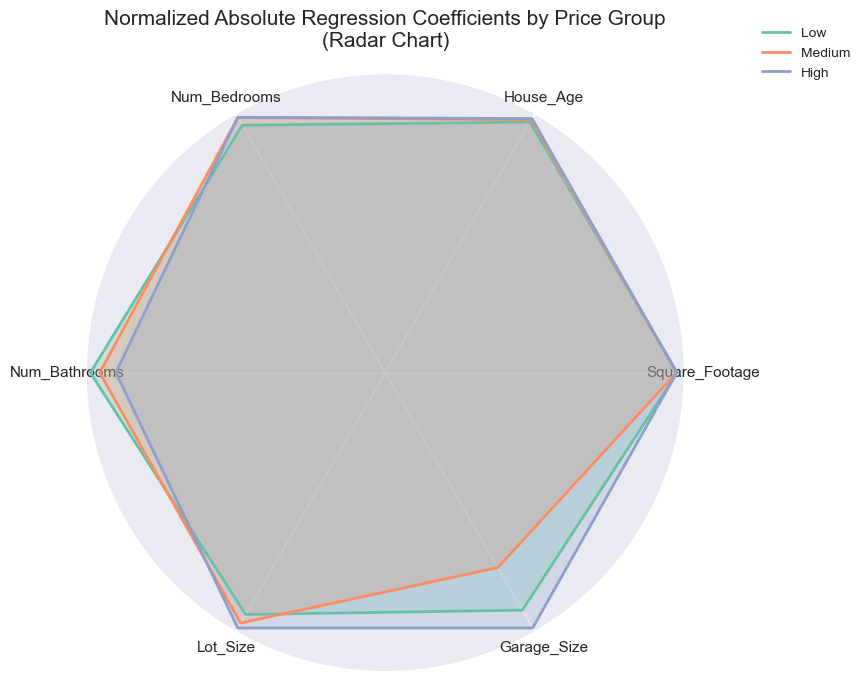

Radar chart saved: radar_coefficients_by_group.png


In [8]:
# Prepare data for radar chart (using coefficients from models, no hardcoding!)
variables = ['const', 'Square_Footage', 'House_Age', 'Num_Bedrooms', 
             'Num_Bathrooms', 'Lot_Size', 'Garage_Size']

# Extract coefficients (absolute value, normalized)
coef_matrix = pd.DataFrame(index=variables)

for group, model in models.items():
    coef_matrix[group] = model.params.values

# Use only the 6 explanatory variables (exclude constant)
plot_vars = ['Square_Footage', 'House_Age', 'Num_Bedrooms', 
             'Num_Bathrooms', 'Lot_Size', 'Garage_Size']

coef_plot = coef_matrix.loc[plot_vars].abs()   # absolute values

# Normalize
normalized_coef = coef_plot.div(coef_plot.max(axis=1), axis=0)

# Radar chart setup
angles = np.linspace(0, 2*np.pi, len(plot_vars), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'projection': 'polar'})

for group in ['Low', 'Medium', 'High']:
    values = normalized_coef[group].tolist() + normalized_coef[group].tolist()[:1]
    ax.plot(angles, values, linewidth=2, label=group)
    ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(plot_vars, fontsize=11)
ax.set_yticks([])
ax.set_title('Normalized Absolute Regression Coefficients by Price Group\n(Radar Chart)', 
             fontsize=15, pad=20)

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()

# Save radar chart
plt.savefig(figures_dir / 'radar_coefficients_by_group.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Radar chart saved: radar_coefficients_by_group.png")

In [9]:
print("\n" + "="*60)
print("Visualization completed successfully!")
print(f"All figures saved to: {figures_dir}")
print("\nGenerated files:")
print("   - regression_coefficients_by_group.png")
print("   - radar_coefficients_by_group.png")
print("\nYou can now check the results/figures/ folder.")


Visualization completed successfully!
All figures saved to: ..\..\results\figures

Generated files:
   - regression_coefficients_by_group.png
   - radar_coefficients_by_group.png

You can now check the results/figures/ folder.
